#Generative AI - The Autoencoder (AE)

Now that you've mastered how computers analyze (Classification, Detection, Segmentation), we move to the "Creation" phase. The simplest "brain" for generating images is the Autoencoder.

**Logic:** Think of an Autoencoder like a person trying to summarize a 500-page book into a 1-page cheat sheet, and then another person trying to rewrite the whole book using only that cheat sheet.

- **The Encoder:** Compresses the input image into a tiny "Latent Space" (the cheat sheet).

- **The Decoder:** Reconstructs the original image from that compressed code.

#Simple Autoencoder

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Input Shape
input_img = layers.Input(shape=(28, 28, 1))

# 2. The Encoder Path
# Instead of a list, we "call" each layer on the previous output
x = layers.Flatten()(input_img)
encoded = layers.Dense(64, activation='relu')(x)

# 3. The Decoder Path
x = layers.Dense(784, activation='sigmoid')(encoded)
decoded = layers.Reshape((28, 28))(x)

# 4. The Full Autoencoder Model
# This connects input_img to decoded directly
autoencoder = models.Model(inputs=input_img, outputs=decoded)

# 5. Optional: Separate Encoder model for future use
encoder = models.Model(inputs=input_img, outputs=encoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()
print("Day 77: Autoencoder fixed using Functional API!")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

Day 77: Autoencoder fixed using Functional API!


#Training 

To see it in action, you just need to feed it the MNIST data. Remember: in an Autoencoder, the input is the target.

In [3]:
# Load data
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Train: Notice x_train is both the input and the label!
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0597 - val_loss: 0.0323
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0264 - val_loss: 0.0210
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0180 - val_loss: 0.0148
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0133 - val_loss: 0.0113
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0104 - val_loss: 0.0090
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0085 - val_loss: 0.0075
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0072 - val_loss: 0.0065
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0057 - val_loss: 0.0053
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0053 - val_loss: 0.0050


#Visualizing Reconstructions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


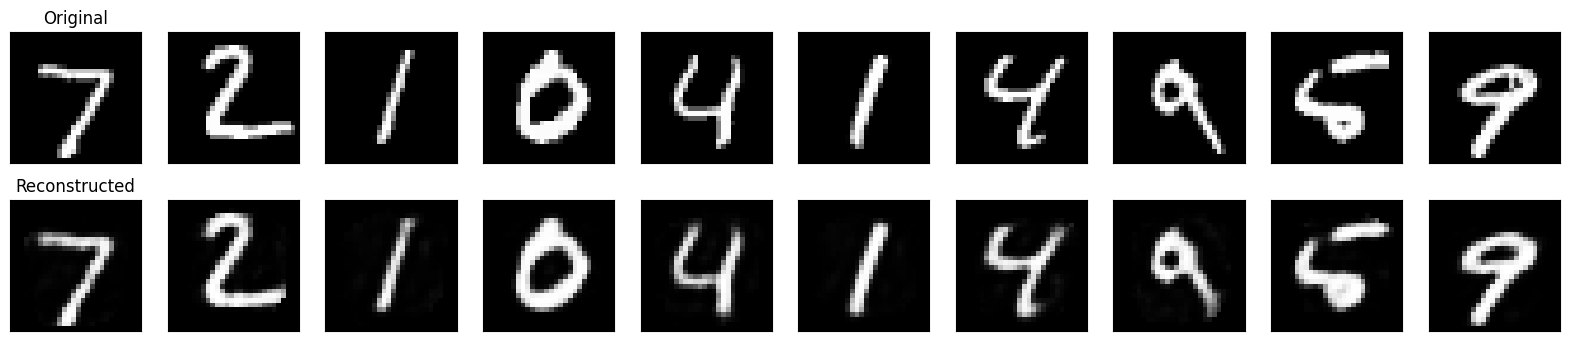

In [4]:
import matplotlib.pyplot as plt

# 1. Take a few test images
n = 10  # Number of digits to display
decoded_imgs = autoencoder.predict(x_test[:n])

plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Original")

    # Display Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Reconstructed")
plt.show()